### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.

In [3]:
import pandas as pd
df= pd.DataFrame({
    "promedio_examenes_cortos":[59,92,72,90,95,87,89,77,76,65,97,42,94,62,91],
    "promedio_final":[64,84,77,80,77,81,80,84,80,69,83,40,78,65,90]
})

df

,promedio_examenes_cortos,promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


In [4]:
# Qué información tengo (x) Variable independiente
# Qué quiero predecir (y) Variable dependiente

y = df["promedio_final"]

x = df["promedio_examenes_cortos"]

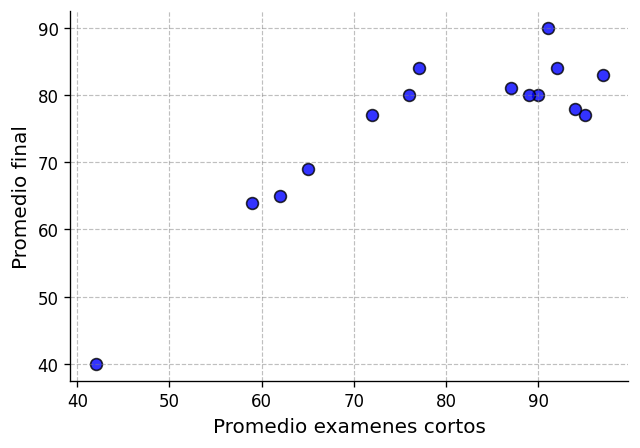

In [5]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [6]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
valor_p:  0.0000


In [7]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,24.526822
promedio_examenes_cortos,0.643180


In [8]:
residuales=modelo.resid

El modelo es:

$$
\hat{y}=24.5268+0.643180x
$$

donde $x$ es el promedio en exámenes cortos.


In [9]:
24.5268+0.643180*(59)

62.47442

In [10]:
#modelo.predict([1,x])

modelo.predict([1,59])

array([62.47443345])

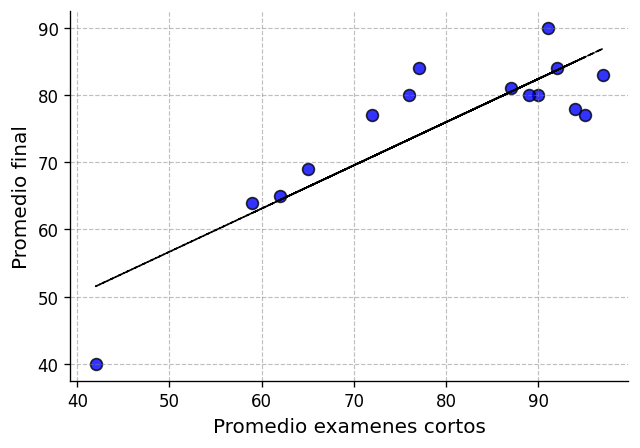

In [11]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

#Fráfico de línea
plt.plot(
    x,y_calculada,
    color='black', #color de la línea
    linewidth=1.0, #grosor de la línea
    linestyle='--', #estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

valor-p (Shapiro) = 0.901827735700704


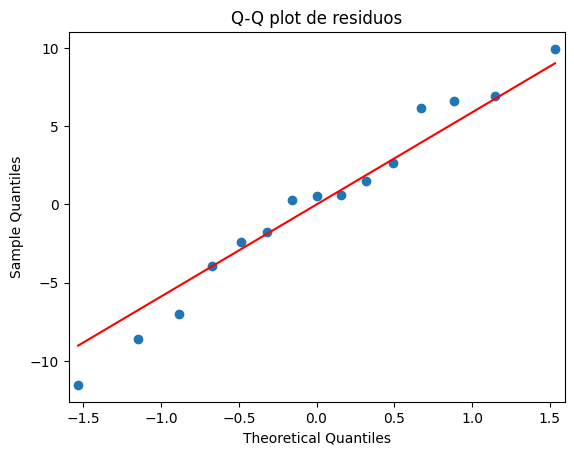

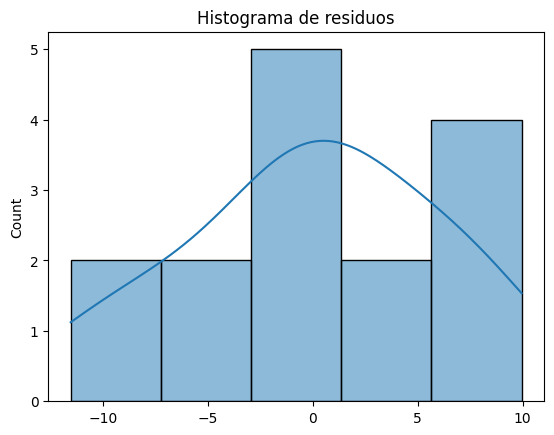

In [12]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#test de Shapiro-Wilk
#H0=Hay normalidad
#H1=No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [13]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2289



In [14]:
residuales

,0
0,1.525567
1,0.300631
2,6.164228
3,-2.413009
4,-8.628908
5,0.516530
6,-1.769829
7,9.948329
8,6.591509
9,2.666487


In [15]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0 (No hay correlación)
# H1: beta_1 ≠ 0 (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols(
'''promedio_final ~ promedio_examenes_cortos''',
data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
promedio_examenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN


### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [16]:
import pandas as pd
df= pd.DataFrame({
    "categoria_de_salario":[11,10,8,5,9,7,3,11,8,7,2,9,8,3],
    "ausencias":[18,17,29,36,11,28,35,14,20,32,39,16,31,40]
})

df

,categoria_de_salario,ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


1.-Establesca una variable dependiente (y) y una variable independiente (x)

*   $y$: es el salario porque....
*   $x$: son las ausencias porque......



In [17]:
# y: salarios
# x: ausencias

y = df["categoria_de_salario"]

x = df["ausencias"]

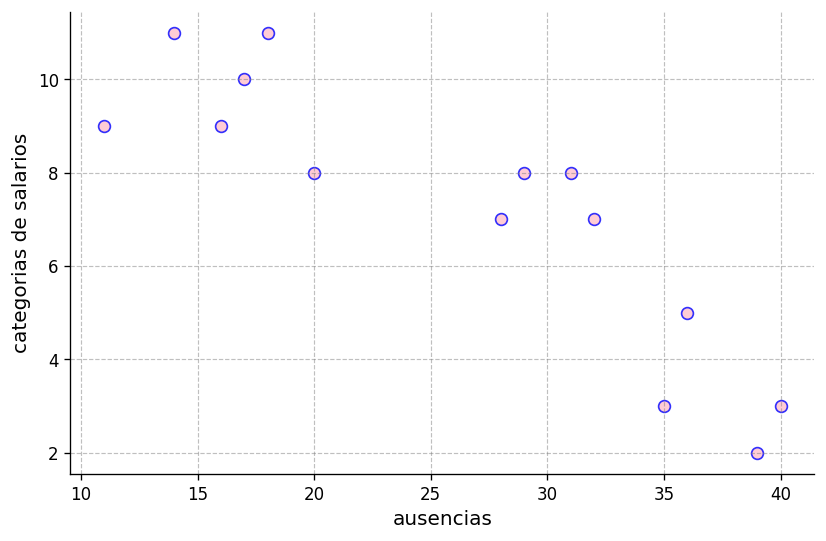

In [18]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(8, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'categorias de salarios', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [19]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.8801
valor_p:  0.0000


El coeficiente de correlación es $r=-0.8801$, este valor indica que la correlación es fuerte, dado que esta muy cerca de 1. Además, el que sea negativa, implica que aumentar las ausencias (x) disminuye el salario (y)

### **5.-Calcule el coeficiente de determinación e interprete el resultado.**

In [20]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [21]:
#Coeficiente de determinación
from sklearn.metrics import r2_score

r2=r2_score(y,y_calculada)

print(f"Coeficiente de determinación: {r2:0.2%}")

Coeficiente de determinación: 77.46%


Con coeficiente de determinación de $r^2=0.7746$ indica que con las ausencias estoy justificando en un 77.46% la variabilidad en los salarios. Por lo que el modelo puede tener una buena capacidad de predicción.

**6.-Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

In [22]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,14.058843
ausencias,-0.261814


La ecuación de la recta es:

$$
\hat{y}=14.058843-0.261814X
$$

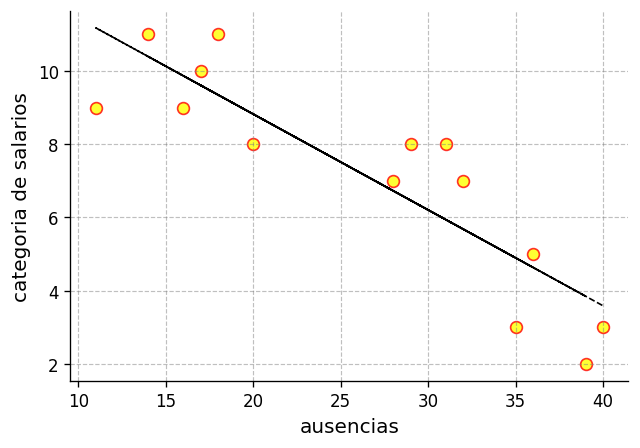

In [23]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='yellow',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

#Fráfico de línea
plt.plot(
    x,y_calculada,
    color='black', #color de la línea
    linewidth=1.0, #grosor de la línea
    linestyle='--', #estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'categoria de salarios', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

**7.-Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ( b1 )**

La recta tiene la forma:

In [24]:
modelo.conf_int(alpha=0.05)

,0,1
const,11.587445,16.530241
ausencias,-0.350638,-0.172989


El verdadero $b_0$ está entre $11.587445$ y $16.530241$ con una confianza del 95%. Esto indica que una persona sin ausencias ($x=0$) tiene una categoría de salario ($y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $-0.350638$ y  $-0.172989$ con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.172989 y 0.350638 en la categoría de salario.

In [25]:
residuales = modelo.resid

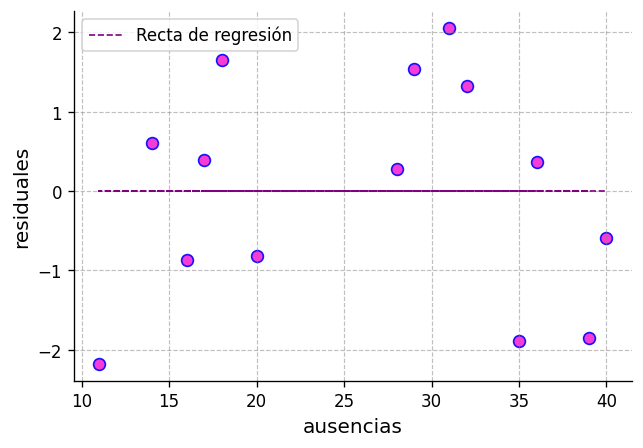

In [26]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    x, y_calculada * 0,
    color='purple',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:



*   Linealidad:Parece que sí
*   Normalidad:Sí cumple con la normaildad, porque....
*   Homoscedasticidad: Sí cumple
*   Independencia: Sí cumple, por que son diferentes personas









**9.-Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 0.4172971767713699


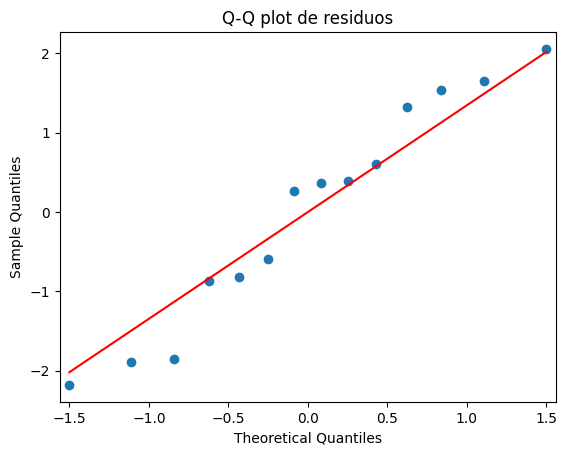

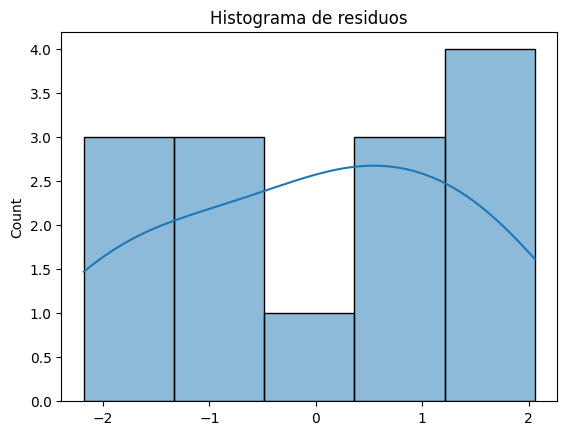

In [27]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# test de Shapiro-Wilk
#n<=30,Histograma o Q-Q plot
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

**10.-Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [28]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.8955



**11.-Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

In [29]:
# mínimo ausencias: 11
# máximo ausencias: 40

# interpolar, valores de x entre 11 y 40

# interpolar 1
y_25 = modelo.predict([1, 25])
y_32 = modelo.predict([1, 32])

print(f"Para x = 25, y =  {y_25[0]: 0.4f}")
print(f"Para x = 32, y =  {y_32[0]: 0.4f}")

Para x = 25, y =   7.5135
Para x = 32, y =   5.6808


In [30]:
df["salario_predicho"] = y_calculada
df

,categoria_de_salario,ausencias,salario_predicho
0,11,18,9.346197
1,10,17,9.608011
2,8,29,6.466247
3,5,36,4.633551
4,9,11,11.178893
5,7,28,6.728060
6,3,35,4.895365
7,11,14,10.393452
8,8,20,8.822570
9,7,32,5.680806


La extrapolación siempre debe hacerse con cuidado, aunque cumpla con todos los supuestos.

In [31]:
# mínimo ausencias: 11
# máximo ausencias: 40

# Extrapolar, valores de x entre 11 y 40

y_10 = modelo.predict([[1, 10]])

print(f"Para x = 10, y =  {y_10[0]: 0.4f}")

Para x = 10, y =   11.4407


Con 10 ausencias se espera que el empleado tenga una categoría de salario de 11. Este valor se obtuvo por medio de extrapolación, por lo que se toma con reservas.

12. **Realice una tabla ANOVA e interprete el resultado.**


In [32]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# y ~ x
modelo_lineal = ols('''categoria_de_salario ~ ausencias''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
ausencias,1.0,87.034348,87.034348,41.243954,0.000033
Residual,12.0,25.322795,2.110233,NaN,NaN


Sí hay correlación porque el valor-p de $0.000033$ es menor a un nivel de significancia $\alpha=0.05$.

En los residuales del anova se puede ver...

### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.


In [33]:
import pandas as pd
df= pd.DataFrame({
    "Gastos_generales":[191,170,272,155,280,173,234,116,153,178],
    "Unidades":[40,42,53,35,56,39,48,30,37,40]
})

df

,Gastos_generales,Unidades
0,191,40
1,170,42
2,272,53
3,155,35
4,280,56
5,173,39
6,234,48
7,116,30
8,153,37
9,178,40


In [34]:
# y: Unidades
# x: Gastos generales

y = df["Unidades"]

x = df["Gastos_generales"]

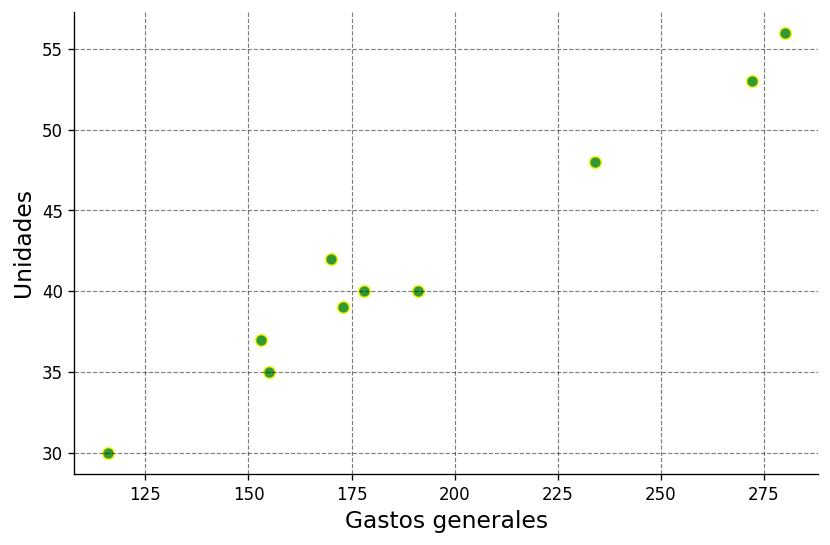

In [35]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(8, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='green',     # color de los puntos
    edgecolor='yellow',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Gastos generales', # etiqueta del eje x
    fontsize=14  # tamaño de fuente
)

plt.ylabel(
    'Unidades', # etiqueta del eje y
    fontsize=14 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="black"
)

In [36]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9835
valor_p:  0.0000


El coeficiente de correlación es  r=0.9835 , este valor indica que la correlación es fuerte, dado que esta muy cerca de 1.

In [37]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [38]:
#Coeficiente de determinación
from sklearn.metrics import r2_score

r2=r2_score(y,y_calculada)

print(f"Coeficiente de determinación: {r2:0.2%}")

Coeficiente de determinación: 96.73%


Con coeficiente de determinación de
r2=96.73%
indica que con los gastos generales estoy justificando en un 96.73%  la variabilidad en las unidades. Por lo que el modelo puede tener una buena capacidad de predicción.

In [39]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params


,0
const,13.360132
Gastos_generales,0.149011


La ecuación de la recta es:

$$
\hat{y}=13.360132+0.149011X
$$

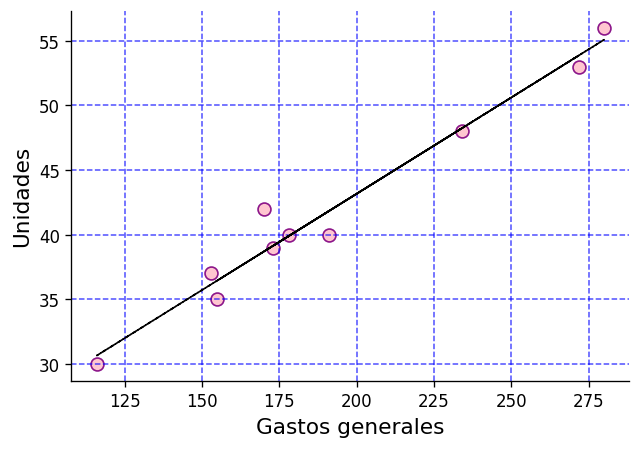

In [40]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='purple',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=60,                 # tamaño de los puntos
)

#Fráfico de línea
plt.plot(
    x,y_calculada,
    color='black', #color de la línea
    linewidth=1.0, #grosor de la línea
    linestyle='--', #estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Gastos generales', # etiqueta del eje x
    fontsize=13  # tamaño de fuente
)

plt.ylabel(
    'Unidades', # etiqueta del eje y
    fontsize=13 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.9,
    alpha=0.7,
    color="blue"
)

In [41]:
modelo.conf_int(alpha=0.05)

,0,1
const,8.920794,17.799471
Gastos_generales,0.126675,0.171347


El verdadero  b0  está entre  8.910794  y  17.799471  con una confianza del 95%. Esto indica que una persona sin gastos generales ( x=0 ) tiene una categoría de unidades ( y ) que está entre estos dos valores.

El verdadero valor de  b1  está entre  0.126675  y  0.171347  con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.126675 y 0.171347 en la categoría de salario.

In [42]:
residuales = modelo.resid

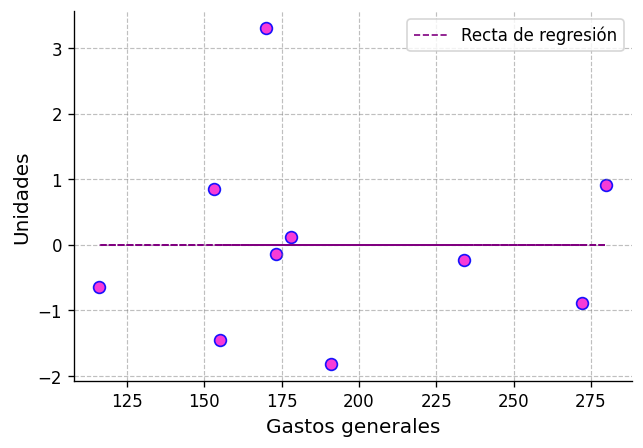

In [43]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    x, y_calculada * 0,
    color='purple',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Gastos generales', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Unidades', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

valor-p (Shapiro) = 0.30963893537419923


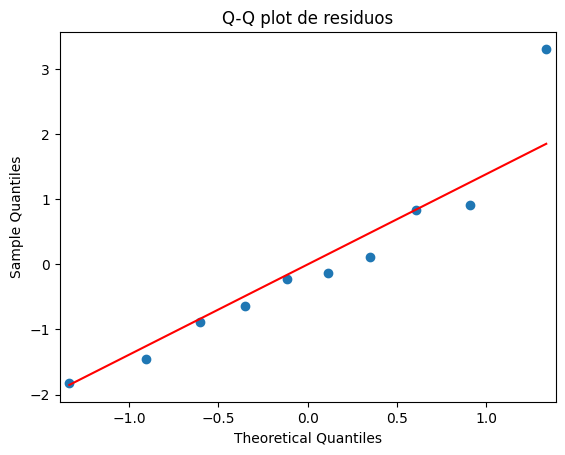

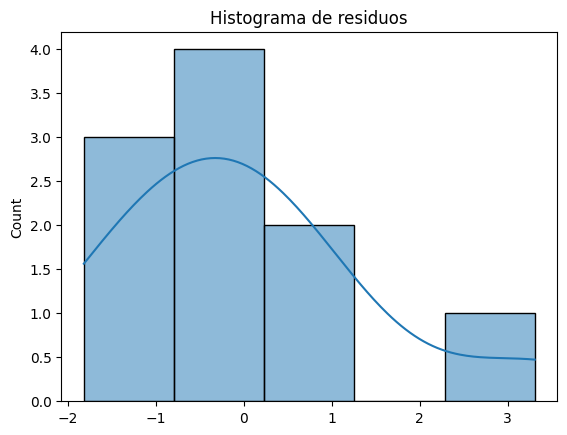

In [44]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# test de Shapiro-Wilk
#n<=30,Histograma o Q-Q plot
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [45]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.6267



In [46]:
df.describe ()

,Gastos_generales,Unidades
count,10.000000,10.000000
mean,192.200000,42.000000
std,53.349581,8.082904
min,116.000000,30.000000
25%,158.750000,37.500000
50%,175.500000,40.000000
75%,223.250000,46.500000
max,280.000000,56.000000


In [47]:
# mínimo Gastos generales: 116
# máximo Gastos generales: 280

# interpolar, valores de x entre 116 y 280

# interpolar 1
y_160 = modelo.predict([1, 160])
y_210 = modelo.predict([1, 210])

print(f"Para x = 160, y =  {y_160[0]: 0.4f}")
print(f"Para x = 210, y =  {y_210[0]: 0.4f}")

Para x = 160, y =   37.2019
Para x = 210, y =   44.6524


In [48]:
# mínimo Gastos generales: 116
# máximo gastos generales: 280

# Extrapolar, valores de x entre 116 y 280

y_110 = modelo.predict([[1, 110]])

print(f"Para x = 110, y =  {y_110[0]: 0.4f}")

Para x = 110, y =   29.7513


In [49]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols(
    '''Gastos_generales ~ Unidades''',
    data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Unidades,1.0,24778.042517,24778.042517,236.669535,3.167080e-07
Residual,8.0,837.557483,104.694685,NaN,NaN


Los resultados del análisis de varianza muestran que el factor unidades tiene un efecto estadísticamente significativo sobre la variable de respuesta, ya que el valor de F = 236.67 y el valor p = 3.17, el cual es mucho menor que el nivel de significancia de 0.05. Por lo tanto, se rechaza la hipótesis nula y se concluye que existen diferencias significativas atribuibles al factor Unidades.

### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construcción de casas (miles) | Ventas de línea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [50]:
import pandas  as pd
df= pd.DataFrame ({
"Construcción de casas":[2.0,2.5,3.2,3.6,3.7,4.0,4.2,4.6,4.8,5.0],
"Ventas de línea blanca":[5.0,5.5,6.0,7.0,7.2,7.7,8.4,9.0,9.7,10.0]
})
df

,Construcción de casas,Ventas de línea blanca
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


In [51]:
# Y: Construcción de casas
# X: Ventas de línea blanca

X =df['Ventas de línea blanca']
Y =df['Construcción de casas']

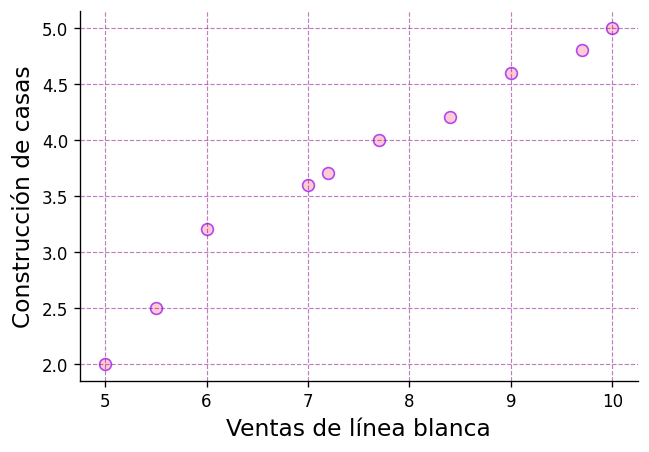

In [52]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="pink",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ventas de línea blanca', # etiqueta del eje x
    fontsize=14  # tamaño de fuente
)

plt.ylabel(
    'Construcción de casas', # etiqueta del eje y
    fontsize=14 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="purple"
)

In [53]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
valor_p:  0.0000


In [54]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,-0.419689
Ventas de línea blanca,0.553601


El valor de 𝑟 =0.553601 indica una correlación positiva muy fuerte entre las dos variables.

El valor 𝑝=-0.419689 está muy por debajo del nivel de significancia 𝛼 =0.05 . ➝ Esto significa que la relación es estadísticamente significativa y se rechaza la hipótesis nula (H0: no existe correlación).

In [55]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

In [56]:
# Coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  96.19%


Un coeficiente de determinación de 96.19% evidencia que el modelo tiene una alta capacidad explicativa.

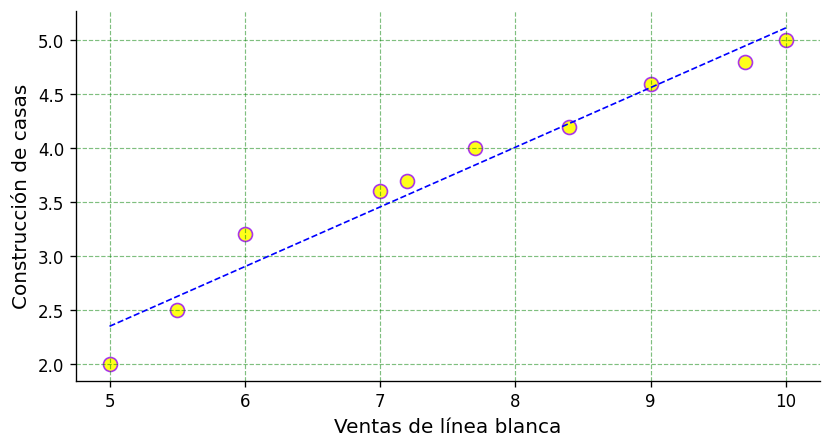

In [57]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(8, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="yellow",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=70,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada,
    color='blue', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ventas de línea blanca', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Construcción de casas', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="green"
)

In [58]:
modelo.conf_int(alpha=0.05)

,0,1
const,-1.113601,0.274223
Ventas de línea blanca,0.463795,0.643407


El modelo de regresión estimado es:

Y=−1.1136+0.4638X

donde X representa las Ventas de línea blanca.

El intercepto (β
0
=−1.1136) indica el valor esperado de la variable de respuesta cuando las ventas de línea blanca son iguales a cero. Aunque su interpretación práctica puede ser limitada si ese valor está fuera del rango observado de los datos, es necesario para definir la recta de regresión.

In [59]:
residuales = modelo.resid

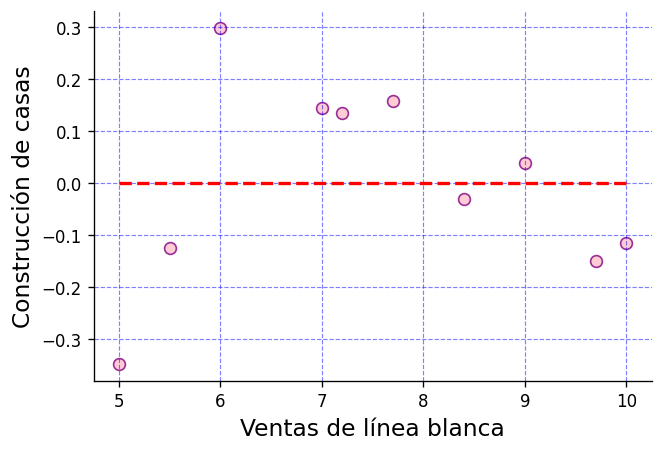

In [60]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X,residuales,      # <---------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color="pink",     # color de los puntos
    edgecolor='purple',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada * 0,# <---------------------------------------------------------
    color='red', #color de la linea
    linewidth=2.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ventas de línea blanca', # etiqueta del eje x
    fontsize=14  # tamaño de fuente
)

plt.ylabel(
    'Construcción de casas', # etiqueta del eje y
    fontsize=14 # tamaño de fuente
)


# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

valor-p (Shapiro) = 0.8696594133467314


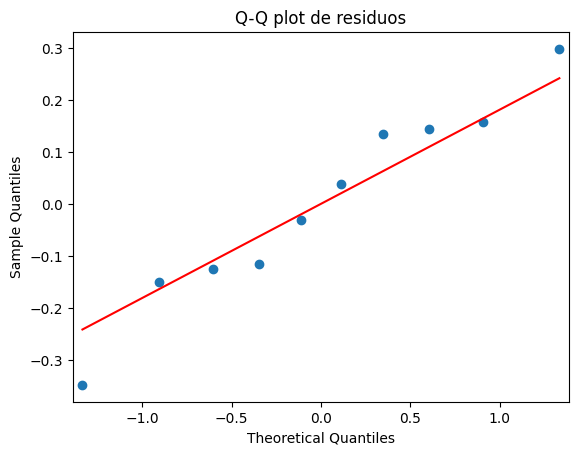

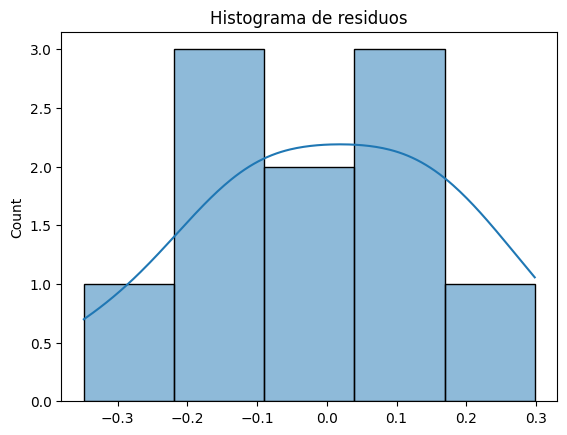

In [61]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#test de shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [62]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0367



In [63]:
df.describe()

,Construcción de casas,Ventas de línea blanca
count,10.000000,10.000000
mean,3.760000,7.550000
std,0.977753,1.732211
min,2.000000,5.000000
25%,3.300000,6.250000
50%,3.850000,7.450000
75%,4.500000,8.850000
max,5.000000,10.000000


In [64]:
# mínimo ventas delinea blanca: 2.000000
# máximo ventas de linea blanca:5.000000

# interpolar, valores de x entre 2.000000 y 5.000000

# interpolar
y_3 = modelo.predict([2.000000,5.000000])
y_4 = modelo.predict([2.000000,5.000000])

print(f"Para x = 25, y =  {y_25[0]: 0.4f}")
print(f"Para x = 32, y =  {y_32[0]: 0.4f}")

Para x = 25, y =   7.5135
Para x = 32, y =   5.6808


In [65]:
# mínimo ventas delinea blanca: 4
# máximo ventas delinea blanca: 6

# Extrapolar, valores de x que no estén entre 4 y 6

y_10 = modelo.predict([[1, 10]])

print(f"Para x = 10, y =  {y_10[0]: 0.4f}")

Para x = 10, y =   5.1163


In [66]:
df.rename(columns={'Construcción de casas':'Y','Ventas de línea blanca':'X'},inplace=True)
df

,Y,X
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


In [67]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''Y  ~ X''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
X,1.0,8.276338,8.276338,202.069951,5.841003e-07
Residual,8.0,0.327662,0.040958,NaN,NaN


Dado que p < 0.05, existe evidencia estadística suficiente para afirmar que la variable X influye significativamente en la variable de respuesta, por lo que el modelo de regresión es estadísticamente significativo.

### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [68]:
import pandas as pd

df = pd.DataFrame({
    'numero_interrupciones': [5,10,10,15,15,20,20,25],
    'calificacion_trabajador': [58,41,45,27,26,12,16,3],

})
df

,numero_interrupciones,calificacion_trabajador
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


In [69]:
# Y: salarios
# X: ausencias

X = df['numero_interrupciones']
Y = df['calificacion_trabajador']

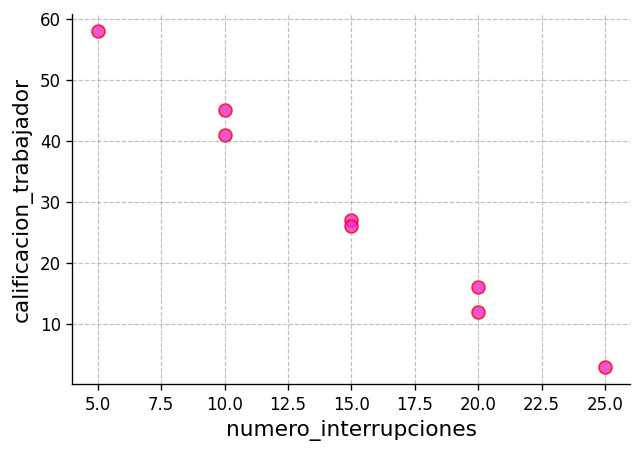

In [70]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=60,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'numero_interrupciones', # etiqueta del eje x
    fontsize=13  # tamaño de fuente
)

plt.ylabel(
    'calificacion_trabajador', # etiqueta del eje y
    fontsize=13 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [71]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlaciòn: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlaciòn: -0.9928
valor_p:  0.0000


In [72]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [73]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  98.58%


Un coeficiente de determinación de 98.58% demuestra que el modelo de regresión explica casi toda la variabilidad de la variable de respuesta, por lo que proporciona un ajuste muy adecuado a los datos observados.

In [74]:
modelo.params

,0
const,70.5
numero_interrupciones,-2.8


El modelo de regresión estimado es:


$$Y=70.5−2.8X$$

donde X representa el número de interrupciones.

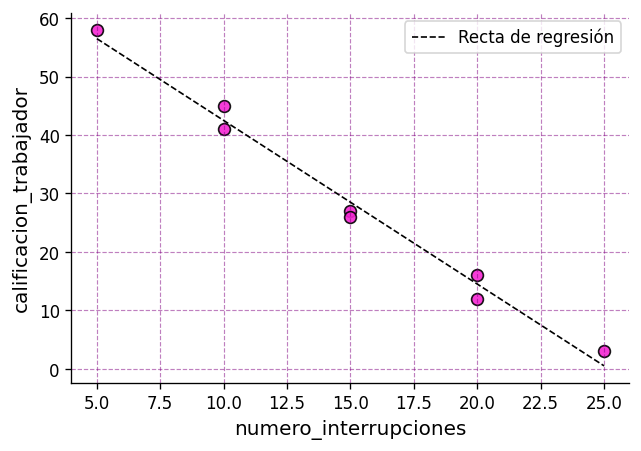

In [75]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'numero_interrupciones', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'calificacion_trabajador', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="purple"
)

plt.legend(
    loc='best',
    fontsize=10
)

In [76]:
modelo.conf_int(alpha=0.05)

,0,1
const,65.051384,75.948616
numero_interrupciones,-3.136296,-2.463704


Dado que el intervalo de confianza del coeficiente de número de interrupciones no contiene el valor cero, se concluye que esta variable tiene un efecto negativo y estadísticamente significativo sobre la variable de respuesta. Además, el efecto estimado se encuentra entre una disminución de 2.46 y 3.14 unidades por cada interrupción adicional.

In [77]:
residuales = modelo.resid

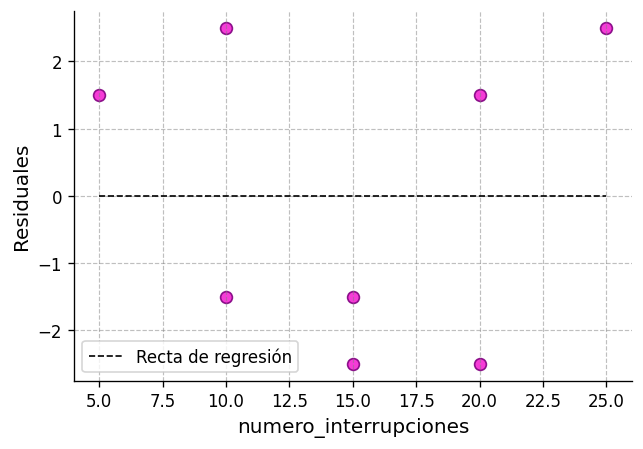

In [79]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='purple',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'numero_interrupciones', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

valor-p (Shapiro) = 0.054816491127669634


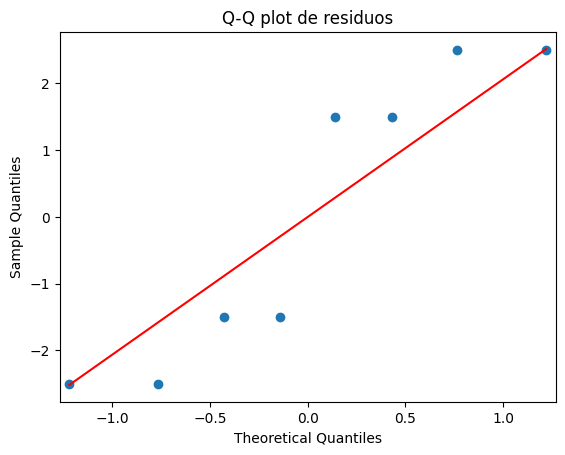

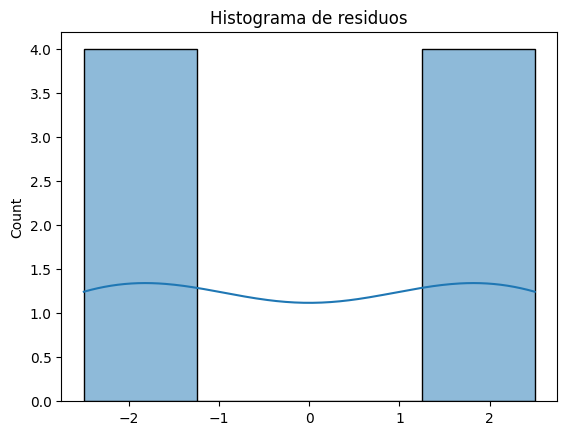

In [80]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [81]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2482



In [83]:
# mínimo interrupciones: 5
# máximo interrupciones: 25

# interpolar, valores de x entre 11 y 40

# interpolar
y_25 = modelo.predict([1, 13])
y_32 = modelo.predict([1, 35])

print(f"Para x = 25, y =  {y_25[0]: 0.4f}")
print(f"Para x = 32, y =  {y_32[0]: 0.4f}")

Para x = 25, y =   34.1000
Para x = 32, y =  -27.5000


In [82]:
df.describe()

,numero_interrupciones,calificacion_trabajador
count,8.000000,8.000000
mean,15.000000,28.500000
std,6.546537,18.462317
min,5.000000,3.000000
25%,10.000000,15.000000
50%,15.000000,26.500000
75%,20.000000,42.000000
max,25.000000,58.000000


In [84]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''numero_interrupciones ~ calificacion_trabajador''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
calificacion_trabajador,1.0,295.725063,295.725063,415.058824,9.090964e-07
Residual,6.0,4.274937,0.712490,NaN,NaN


Debido a que p < 0.05, existe evidencia estadística suficiente para afirmar que la calificación del trabajador tiene una influencia significativa sobre la variable de respuesta, por lo que el modelo de regresión es estadísticamente significativo.